**TITLE :  MedScanAI: Classical Machine Learning Approach for Pneumonia Detection**

**1. Dataset Download**

In [ ]:
!pip install -q scikit-image opencv-python-headless

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"subhasree146","key":"8bf7064c01509ab428ead05c60f7801f"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle configured successfully!")

Kaggle configured successfully!


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:13<00:00, 18.5MB/s]



In [ ]:
base_path = "/content/chest_xray"

for folder in ["train", "val", "test"]:
    print(folder)
    print(os.listdir(os.path.join(base_path, folder)))
    print("-" * 30)

train
['NORMAL', 'PNEUMONIA']
------------------------------
val
['NORMAL', 'PNEUMONIA']
------------------------------
test
['NORMAL', 'PNEUMONIA']
------------------------------


**2. Data Preprocessing**

In [ ]:
IMG_SIZE = (128, 128)

def load_and_preprocess(folder_path, label, img_size=IMG_SIZE):
    images, labels = [], []
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, img_size)
        img = cv2.equalizeHist(img)
        img = img.astype("float32") / 255.0
        images.append(img)
        labels.append(label)
    return images, labels

In [ ]:
train_dir = "/content/chest_xray/train"
test_dir  = "/content/chest_xray/test"

normal_imgs, normal_labels = load_and_preprocess(os.path.join(train_dir, "NORMAL"), label=0)
pneu_imgs, pneu_labels     = load_and_preprocess(os.path.join(train_dir, "PNEUMONIA"), label=1)

X_full = np.array(normal_imgs + pneu_imgs)
y_full = np.array(normal_labels + pneu_labels)

print("Total training images loaded:", X_full.shape)
print("Class distribution -> NORMAL:", np.sum(y_full == 0), " PNEUMONIA:", np.sum(y_full == 1))

Total training images loaded: (5216, 128, 128)
Class distribution -> NORMAL: 1341  PNEUMONIA: 3875


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (4172, 128, 128) Val: (1044, 128, 128)


In [ ]:
normal_test, normal_test_labels = load_and_preprocess(os.path.join(test_dir, "NORMAL"), label=0)
pneu_test, pneu_test_labels     = load_and_preprocess(os.path.join(test_dir, "PNEUMONIA"), label=1)

X_test = np.array(normal_test + pneu_test)
y_test = np.array(normal_test_labels + pneu_test_labels)

print("Test:", X_test.shape)

Test: (624, 128, 128)


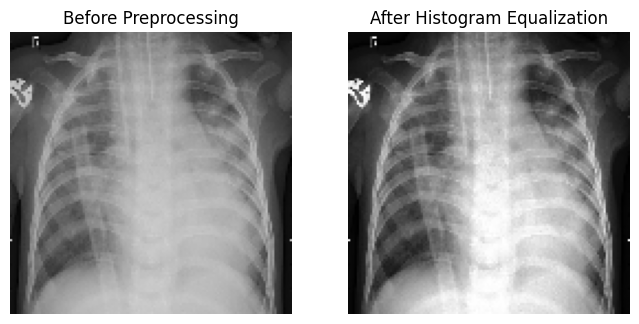

In [ ]:
sample_path = os.path.join(train_dir, "PNEUMONIA", os.listdir(os.path.join(train_dir, "PNEUMONIA"))[0])
raw = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
raw_resized = cv2.resize(raw, IMG_SIZE)
processed = cv2.equalizeHist(raw_resized)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(raw_resized, cmap="gray")
plt.title("Before Preprocessing")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed, cmap="gray")
plt.title("After Histogram Equalization")
plt.axis("off")
plt.show()

**Feature Extraction**

In [ ]:
def extract_hog_features(images):
    """Extracts HOG features for a list/array of grayscale images."""
    features = []
    for img in images:
        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True
        )
        features.append(feat)
    return np.array(features)

In [ ]:
X_train_hog = extract_hog_features(X_train)
X_val_hog   = extract_hog_features(X_val)
X_test_hog  = extract_hog_features(X_test)

print("HOG feature vector shape:", X_train_hog.shape)

HOG feature vector shape: (4172, 8100)


**4. Feature scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_val_scaled   = scaler.transform(X_val_hog)
X_test_scaled  = scaler.transform(X_test_hog)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original feature size:", X_train_scaled.shape[1])
print("Reduced feature size (95% variance):", X_train_pca.shape[1])

Original feature size: 8100
Reduced feature size (95% variance): 1549


**5. Model Training**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "SVM (RBF Kernel)": SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42)
}

val_results = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    val_pred = model.predict(X_val_pca)
    acc = accuracy_score(y_val, val_pred)
    val_results[name] = acc
    print(f"{name} -> Validation Accuracy: {acc:.4f}")

Logistic Regression -> Validation Accuracy: 0.9713
Random Forest -> Validation Accuracy: 0.7921
SVM (RBF Kernel) -> Validation Accuracy: 0.9751


**6. Test set Evaluation**


========== Logistic Regression ==========
Test Accuracy: 0.7260
              precision    recall  f1-score   support

      NORMAL       0.92      0.29      0.45       234
   PNEUMONIA       0.70      0.98      0.82       390

    accuracy                           0.73       624
   macro avg       0.81      0.64      0.63       624
weighted avg       0.78      0.73      0.68       624



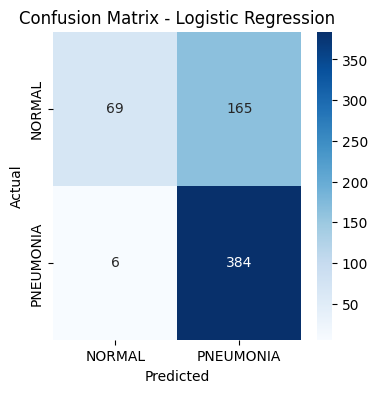


========== Random Forest ==========
Test Accuracy: 0.6282
              precision    recall  f1-score   support

      NORMAL       1.00      0.01      0.02       234
   PNEUMONIA       0.63      1.00      0.77       390

    accuracy                           0.63       624
   macro avg       0.81      0.50      0.39       624
weighted avg       0.77      0.63      0.49       624



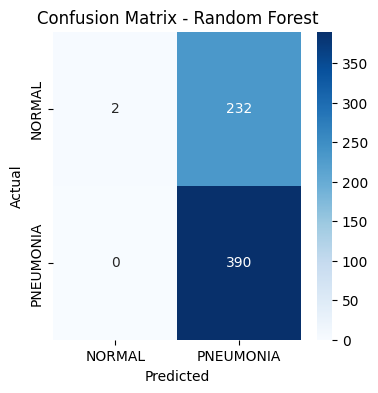


========== SVM (RBF Kernel) ==========
Test Accuracy: 0.7308
              precision    recall  f1-score   support

      NORMAL       0.96      0.29      0.45       234
   PNEUMONIA       0.70      0.99      0.82       390

    accuracy                           0.73       624
   macro avg       0.83      0.64      0.64       624
weighted avg       0.80      0.73      0.68       624



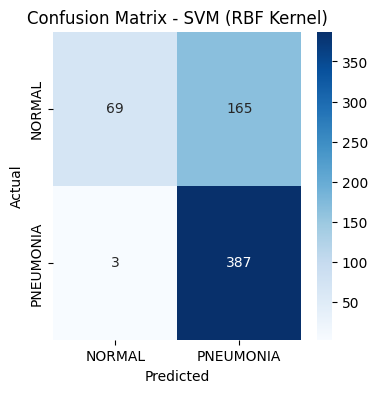

In [ ]:
test_results = {}

for name, model in models.items():
    test_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, test_pred)
    test_results[name] = acc

    print(f"\n========== {name} ==========")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, test_pred, target_names=["NORMAL", "PNEUMONIA"]))

    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

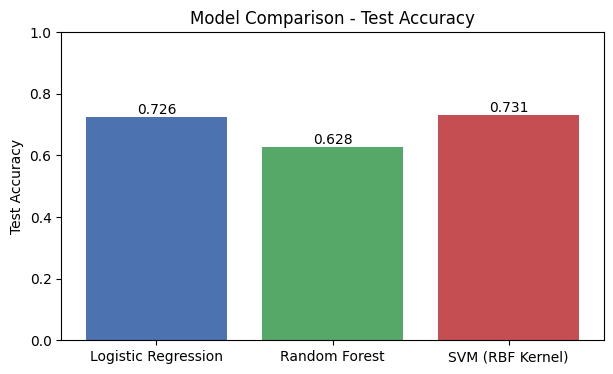

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(test_results.keys(), test_results.values(), color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Test Accuracy")
plt.title("Model Comparison - Test Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(test_results.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.show()

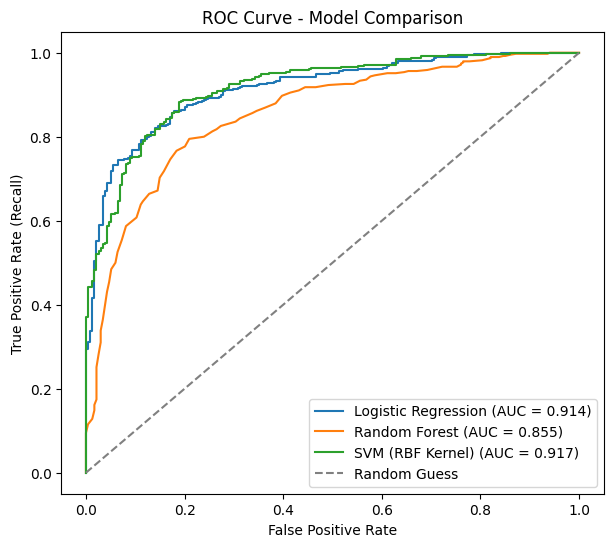

In [ ]:
#roc curve
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_pca)[:, 1]
    else:
        y_score = model.decision_function(X_test_pca)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Model Comparison")
plt.legend(loc="lower right")
plt.show()

**7. Save Best Model**

In [ ]:
best_model_name = max(test_results, key=test_results.get)
best_model = models[best_model_name]

print("Best model:", best_model_name, "with test accuracy:", test_results[best_model_name])

joblib.dump(best_model, "pneumonia_best_ml_model.pkl")
joblib.dump(scaler, "hog_scaler.pkl")
joblib.dump(pca, "hog_pca.pkl")

print("Saved: pneumonia_best_ml_model.pkl, hog_scaler.pkl, hog_pca.pkl")

Best model: SVM (RBF Kernel) with test accuracy: 0.7307692307692307
Saved: pneumonia_best_ml_model.pkl, hog_scaler.pkl, hog_pca.pkl


In [ ]:
#Add Class Imbalance Handling (SMOTE)
#This imbalance is causing poor NORMAL prediction.

In [ ]:
!pip install -q imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_pca,
    y_train
)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_smote))

Before SMOTE: [1073 3099]
After SMOTE : [3099 3099]


In [ ]:
#Train SVM Again Using SMOTE Data
#SVM beacuse among other model its performance best

In [ ]:
svm_smote = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_smote.fit(
    X_train_smote,
    y_train_smote
)

SVC(C=10, class_weight='balanced', probability=True, random_state=42)

In [ ]:
y_pred_smote = svm_smote.predict(X_test_pca)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test,
    y_pred_smote
)

print("SMOTE SVM Accuracy:", acc)

SMOTE SVM Accuracy: 0.7371794871794872


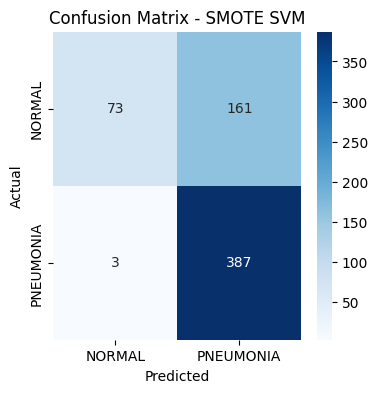

In [ ]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_smote
)

plt.figure(figsize=(4,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL","PNEUMONIA"],
    yticklabels=["NORMAL","PNEUMONIA"]
)

plt.title("Confusion Matrix - SMOTE SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#Calculate Sensitivity and Specificity

In [ ]:
TN, FP, FN, TP = cm.ravel()

In [ ]:
sensitivity = TP/(TP+FN)

In [ ]:
specificity = TN/(TN+FP)

In [ ]:
print("Sensitivity :", sensitivity)
print("Specificity :", specificity)

Sensitivity : 0.9923076923076923
Specificity : 0.31196581196581197


In [ ]:
##XGBoost Model

In [ ]:

!pip install -q xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(
    X_test_pca
)

In [ ]:
xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.7419871794871795


In [ ]:
#Compare All Models

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "SMOTE SVM",
        "XGBoost"
    ],
    "Accuracy":[
        test_results["Logistic Regression"],
        test_results["Random Forest"],
        test_results["SVM (RBF Kernel)"],
        acc,
        xgb_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.725962
1,Random Forest,0.628205
2,SVM,0.730769
3,SMOTE SVM,0.737179
4,XGBoost,0.741987


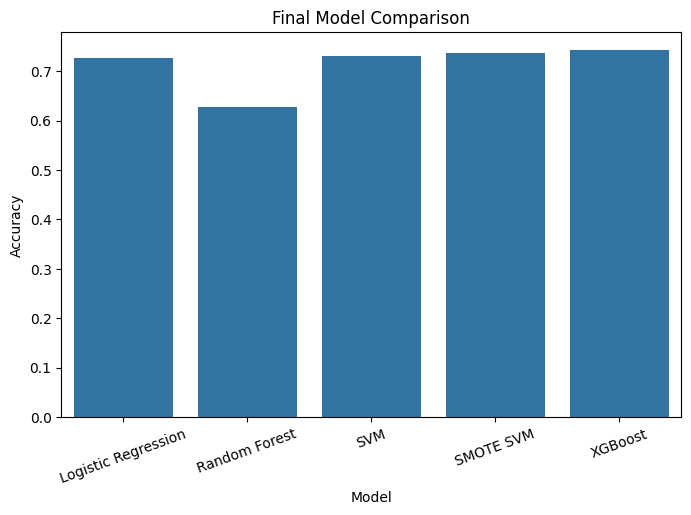

In [ ]:
#Plot Final Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.xticks(rotation=20)
plt.title("Final Model Comparison")
plt.show()

In [ ]:
#Hyperparameter Tuning for SVM

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C':[1,10,100],
    'gamma':[0.001,0.01,0.1],
    'kernel':['rbf']
}

In [ ]:
grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

GridSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [1, 10, 100], 'gamma': [0.001, 0.01, 0.1],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


In [ ]:
best_svm = grid.best_estimator_

In [ ]:
#Evaluate Best SVM

In [ ]:
best_pred = best_svm.predict(
    X_test_pca
)

best_acc = accuracy_score(
    y_test,
    best_pred
)

print("Best Tuned SVM Accuracy:", best_acc)

Best Tuned SVM Accuracy: 0.625


In [ ]:
#5-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(
    best_svm,
    X_train_smote,
    y_train_smote,
    cv=5
)

In [ ]:
print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())

CV Scores: [0.84516129 0.85564516 0.99516129 0.99596449 0.99596449]
Mean Accuracy: 0.9375793433830613


These values are suspiciously high.

Because you applied SMOTE before Cross Validation.

This causes data leakage.

corect CV method

In [ ]:
from imblearn.pipeline import Pipeline

In [ ]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(kernel='rbf', C=10))
])

In [ ]:
scores = cross_val_score(
    pipeline,
    X_train_pca,
    y_train,
    cv=5
)

In [ ]:
print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())

CV Scores: [0.96886228 0.97245509 0.97721823 0.97122302 0.97002398]
Mean Accuracy: 0.9719565186174414


#ANOVA Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [ ]:
selector = SelectKBest(
    score_func=f_classif,
    k=2000
)

X_train_fs = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_fs = selector.transform(
    X_test_scaled
)

X_val_fs = selector.transform(
    X_val_scaled
)

In [ ]:
print(X_train_scaled.shape)
print(X_train_fs.shape)

(4172, 8100)
(4172, 2000)


In [ ]:
#PCA

In [ ]:
pca_fs = PCA(
    n_components=0.95,
    random_state=42
)

X_train_fs_pca = pca_fs.fit_transform(
    X_train_fs
)

X_test_fs_pca = pca_fs.transform(
    X_test_fs
)

X_val_fs_pca = pca_fs.transform(
    X_val_fs
)

Since XGBoost model best among all so train again

In [ ]:
xgb_fs = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_fs.fit(
    X_train_fs_pca,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred_fs = xgb_fs.predict(
    X_test_fs_pca
)

acc_fs = accuracy_score(
    y_test,
    pred_fs
)

print(acc_fs)

0.7067307692307693


Feature Selection reduced performance.

XGBoost + PCA = 74.20% best

In [ ]:
#LDA Experiment

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_train_lda = lda.fit_transform(
    X_train_scaled,
    y_train
)

X_test_lda = lda.transform(
    X_test_scaled
)

In [ ]:
lr_lda = LogisticRegression()

lr_lda.fit(
    X_train_lda,
    y_train
)

pred_lda = lr_lda.predict(
    X_test_lda
)

print(
    accuracy_score(
        y_test,
        pred_lda
    )
)

0.7163461538461539


In [ ]:
#Explainable AI (SHAP)

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(
    xgb
)

shap_values = explainer.shap_values(
    X_test_pca[:100]
)

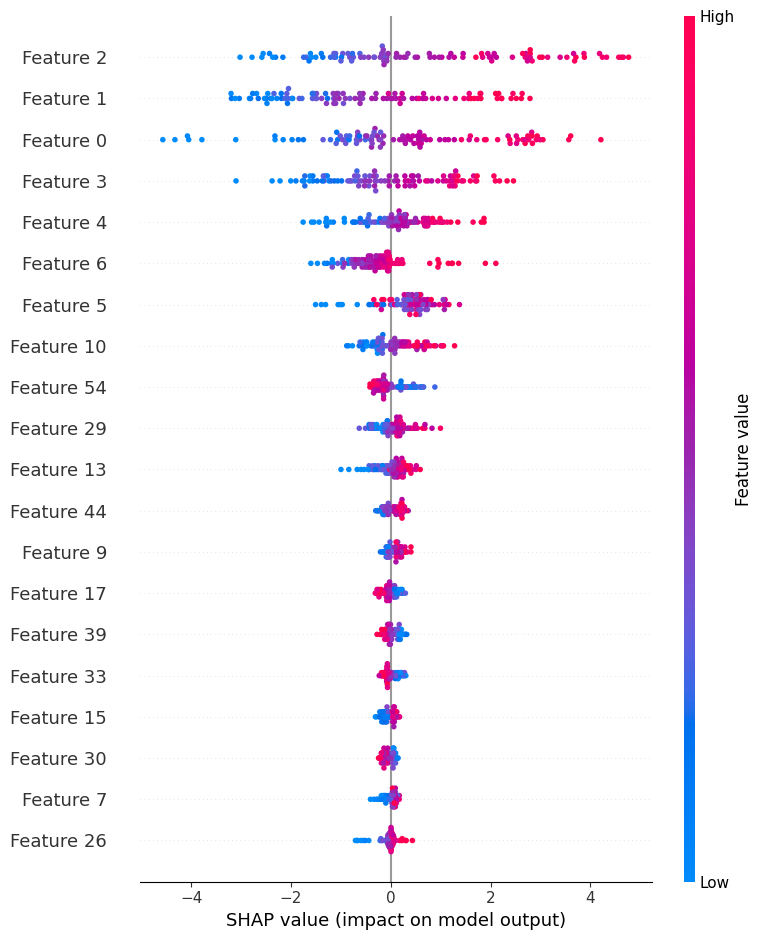

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_pca[:100]
)

**Color Meaning**

Red = High feature value

Blue = Low feature value

**X-axis Meaning**

Positive SHAP value → pushes prediction toward Pneumonia

Negative SHAP value → pushes prediction toward Normal

#HOG vs LBP vs HOG+LBP

In [ ]:
#LBP Feature Extraction
from skimage.feature import local_binary_pattern

In [ ]:
#LBP Feature Function
def extract_lbp_features(images):

    features = []

    radius = 1
    n_points = 8 * radius

    for img in images:

        lbp = local_binary_pattern(
            img,
            n_points,
            radius,
            method='uniform'
        )

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_points + 3),
            range=(0, n_points + 2)
        )

        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        features.append(hist)

    return np.array(features)

In [ ]:
#Experiment A: LBP Only

In [ ]:
X_train_lbp = extract_lbp_features(X_train)
X_test_lbp = extract_lbp_features(X_test)

In [ ]:
scaler_lbp = StandardScaler()

X_train_lbp = scaler_lbp.fit_transform(X_train_lbp)
X_test_lbp = scaler_lbp.transform(X_test_lbp)

In [ ]:
xgb_lbp = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_lbp.fit(X_train_lbp, y_train)

pred_lbp = xgb_lbp.predict(X_test_lbp)

acc_lbp = accuracy_score(y_test, pred_lbp)

print(acc_lbp)

0.7580128205128205


LBP + XGBoost = 0.7580128205128205

In [ ]:
#Experiment B: HOG + LBP

In [ ]:
X_train_hog_lbp = np.hstack([
    X_train_hog,
    X_train_lbp
])

X_test_hog_lbp = np.hstack([
    X_test_hog,
    X_test_lbp
])

In [ ]:
scaler_hl = StandardScaler()

X_train_hog_lbp = scaler_hl.fit_transform(
    X_train_hog_lbp
)

X_test_hog_lbp = scaler_hl.transform(
    X_test_hog_lbp
)

In [ ]:
pca_hl = PCA(
    n_components=0.95,
    random_state=42
)

X_train_hog_lbp = pca_hl.fit_transform(
    X_train_hog_lbp
)

X_test_hog_lbp = pca_hl.transform(
    X_test_hog_lbp
)

In [ ]:
xgb_hl = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_hl.fit(
    X_train_hog_lbp,
    y_train
)

pred_hl = xgb_hl.predict(
    X_test_hog_lbp
)

acc_hl = accuracy_score(
    y_test,
    pred_hl
)

print(acc_hl)

0.7083333333333334


#CLAHE vs Histogram Equalization

Since Histogram Equalization + LBP + XGBoost = 75.80%

CLAHE + LBP + XGBoost =?

In [ ]:
def load_and_preprocess(folder_path, label, img_size=IMG_SIZE):
    images, labels = [], []

    for fname in os.listdir(folder_path):

        fpath = os.path.join(folder_path, fname)

        img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, img_size)

        img = cv2.equalizeHist(img)

        img = img.astype("float32") / 255.0

        images.append(img)
        labels.append(label)

    return images, labels

In [ ]:
def load_and_preprocess_clahe(folder_path, label, img_size=IMG_SIZE):

    images = []
    labels = []

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    for fname in os.listdir(folder_path):

        fpath = os.path.join(folder_path, fname)

        img = cv2.imread(
            fpath,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            img_size
        )

        img = clahe.apply(img)

        img = img.astype("float32") / 255.0

        images.append(img)
        labels.append(label)

    return images, labels

In [ ]:
normal_test, normal_test_labels = load_and_preprocess_clahe(
    os.path.join(test_dir,"NORMAL"),
    label=0
)

pneu_test, pneu_test_labels = load_and_preprocess_clahe(
    os.path.join(test_dir,"PNEUMONIA"),
    label=1
)

In [ ]:
X_test = np.array(normal_test + pneu_test)

y_test = np.array(
    normal_test_labels +
    pneu_test_labels
)

print(X_test.shape)
print(y_test.shape)

(624, 128, 128)
(624,)


In [ ]:
normal_imgs, normal_labels = load_and_preprocess_clahe(
    os.path.join(train_dir,"NORMAL"),
    label=0
)

pneu_imgs, pneu_labels = load_and_preprocess_clahe(
    os.path.join(train_dir,"PNEUMONIA"),
    label=1
)

In [ ]:
X_full = np.array(
    normal_imgs + pneu_imgs
)

y_full = np.array(
    normal_labels + pneu_labels
)

In [ ]:
#train
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

In [ ]:
#Extract LBP Features
X_train_lbp = extract_lbp_features(X_train)

X_test_lbp = extract_lbp_features(X_test)

In [ ]:
#Scale Features
from sklearn.preprocessing import StandardScaler

scaler_lbp = StandardScaler()

X_train_lbp = scaler_lbp.fit_transform(
    X_train_lbp
)

X_test_lbp = scaler_lbp.transform(
    X_test_lbp
)

In [ ]:
#Train XGBoost
from xgboost import XGBClassifier

xgb_lbp = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_lbp.fit(
    X_train_lbp,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred_lbp = xgb_lbp.predict(
    X_test_lbp
)

acc_lbp = accuracy_score(
    y_test,
    pred_lbp
)

print("CLAHE + LBP + XGBoost Accuracy:",
      acc_lbp)

CLAHE + LBP + XGBoost Accuracy: 0.7003205128205128
